# Como um modelo aprende
## Um treino, do texto à escolha do melhor modelo

Você vai acompanhar uma rede pequena que recebe **8 caracteres e tenta prever o próximo**.
Ao terminar, deverá conseguir explicar de onde vem a resposta correta, o que muda em cada passo e por que continuar treinando pode piorar o resultado.

**Percurso:** dados → exemplos → previsão → erro → atualização → treino → avaliação.

**O que estamos treinando:** uma rede com embeddings e uma camada oculta, inspirada em Bengio et al. (2003), adaptada para caracteres. Embeddings são vetores aprendidos que representam cada caractere. Este exemplo compartilha o objetivo de prever o próximo token e as etapas básicas de otimização com modelos maiores; a arquitetura aqui é uma MLP, sem atenção.

In [1]:
import math
import time
from textwrap import fill
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
COR_TREINO, COR_VAL = "#147D73", "#C86A24"
print("Ambiente pronto. NumPy", np.__version__)

Ambiente pronto. NumPy 2.5.3


## 1. Os dados: que texto vamos ensinar?

**Corpus** é o conjunto de textos usados no experimento. Aqui são 33 documentos curtos sobre modelos de linguagem, extraídos de um material de estudo (texto e notas de uma apresentação anterior). Os dados estão embutidos neste arquivo.

Vamos remover cabeçalhos repetidos, linhas com chaves de código, fragmentos com menos de cinco palavras e duplicatas exatas. Essas são escolhas específicas deste corpus: uma frase curta pode ser útil, e código é importante quando o objetivo é aprender programação.

**Observe a saída:** compare o mesmo documento antes e depois. A limpeza muda o que será aprendido, por isso merece inspeção.

In [2]:
#@title Dados do experimento (execute; leitura opcional)
# Cada lista interna contém as linhas de um documento.
CORPUS_BRUTO = [['SEMINÁRIO · EQUIPE DE TREINAMENTO E FINE-TUNING', 'Do texto ao texto', 'Como uma frase se transforma nos números processados por um LLM', 'e volta a se transformar em texto', 'a frase', 'O', 'limite', 'é', 'o', 'cé', 'u', 'os números', '46', '71080', '4046', '297', '64934', '84', 'tokenizador', 'decodificador', 'A pergunta', 'Uma frase entra como letras e sai como letras. No meio, só existem matrizes de números. Este seminário percorre o caminho inteiro, nos dois sentidos.', 'Conteúdo da seção 3', 'tokens, IDs e vocabulário', 'BPE e treino de tokenizers', 'português × inglês', 'embeddings de token e posição', 'Transformer decoder', 'logits, softmax e previsão', 'Universidade Federal de Goiás · Inteligência Artificial · 2026', "Abertura (1 min). Mostrar a tira: em cima a frase como o humano lê, embaixo o que o modelo realmente recebe. Note que 'céu' virou dois pedaços: ' cé' + 'u'. Todo o seminário é explicar essas duas setas: o tokenizador (descer) e o decodificador (subir). IDs reais medidos com o tokenizer cl100k_base (GPT-4)."],
    ['ROTEIRO', 'Estrutura da apresentação', 'Roteiro', '2', '1', 'Pergunta e motivação', 'Por que a tokenização decide o que o modelo consegue fazer.', '2', 'Intuição e mapa conceitual', 'O caminho completo em um diagrama, sem matemática.', '3', 'Explicação técnica', 'Tokens, BPE, embeddings, decoder, logits e softmax.', 'nosso conteúdo mínimo', '4', 'Visualização e artefato', 'Notebook que mostra cada etapa em uma frase real.', '5', 'Literatura e projeto', 'Artigos de referência e conexão com fine-tuning.', '6', 'Síntese e limites', 'O que fica de pé e o que a tokenização quebra.', 'Roteiro (30 s). As seis partes são a estrutura pedida pelo professor. A parte 3 é a mais longa: é onde entra o conteúdo mínimo da nossa equipe. As demais seções já vêm com slides prontos para cada integrante ajustar.'],
    ['1', 'Pergunta e motivação', 'O funil por onde passa tudo que um LLM lê e escreve.', 'A pergunta orientadora', 'Por que tokens importam', 'O custo em português', '3', 'Troca de apresentador. Anunciar a seção em uma frase e emendar: nesta parte só enquadramos o problema, a matemática vem na seção 3.'],
    ['1 · PERGUNTA E MOTIVAÇÃO', 'A pergunta orientadora', '1 · Pergunta e motivação', '4', 'Como uma frase se transforma nos números processados por um LLM', 'e volta a se transformar em texto?', '1', 'Ida', 'texto → números', 'O tokenizador quebra a frase em peças do vocabulário e troca cada peça por um inteiro. Depois cada inteiro vira um vetor.', '2', 'Meio', 'números → números', 'O decoder mistura os vetores com atenção e devolve, para a última posição, uma pontuação para cada token possível.', '3', 'Volta', 'números → texto', 'Softmax transforma pontuações em probabilidades, escolhemos um token e ele volta como entrada. O ciclo recomeça.', 'Cada uma das três etapas é uma parte da seção 3.', 'Enquadrar a pergunta (1 min). Ler a pergunta em voz alta. Deixar claro que a resposta tem três movimentos: ida, meio e volta. Tudo que vier depois encaixa em um desses três.'],
    ['1 · PERGUNTA E MOTIVAÇÃO', 'Por que isso não é um detalhe de implementação', '1 · Pergunta e motivação', '5', 'O token é a unidade de conta de tudo: contexto, custo, velocidade e até os erros famosos dos LLMs.', 'Contexto e custo', 'A janela de contexto e o preço da API são medidos em tokens, nunca em palavras. O mesmo texto em português ocupa mais janela que em inglês.', 'O modelo não vê letras', 'Ele vê IDs. Por isso erra ao contar letras de uma palavra ou ao somar números longos: a informação de caractere foi embrulhada dentro do token.', 'Fine-tuning herda o tokenizer', 'Ao ajustar um modelo, o vocabulário vem congelado do pré-treino. Trocar ou estender o vocabulário exige redimensionar a matriz de embeddings.', '1,32×', 'mais tokens em português', 'O mesmo parágrafo sobre modelos de linguagem, medido com o tokenizer cl100k_base (GPT-4):', '45 tokens em português contra 34 em inglês. Na prática: menos texto cabe na janela, cada chamada custa mais e o treino em português consome mais passos para a mesma quantidade de informação.', 'Medição própria com tiktoken · cl100k_base', 'Motivação (1-2 min). O número 1,32 foi medido por nós com a biblioteca tiktoken, não é estimativa. Se perguntarem: parágrafo de 3 frases sobre modelos de linguagem, 45 tokens em PT contra 34 em EN. Bom gancho para a parte 3: por que o português fragmenta mais.'],
    ['2', 'Intuição e mapa conceitual', 'O caminho inteiro em um diagrama, antes da matemática.', 'O pipeline completo', 'Três intuições que bastam', '6', 'Avisar que esta seção é deliberadamente sem fórmula: primeiro o mapa, depois o detalhe. Quem se perder na seção 3 pode voltar aqui.'],
    ['2 · INTUIÇÃO E MAPA CONCEITUAL', 'O mapa: onde cada conceito entra', '2 · Intuição e mapa conceitual', '7', 'Sete estágios. Os quatro do meio são puro cálculo numérico — o texto só existe nas pontas.', 'Texto', '"O limite é o"', 'Tokens', 'peças do', 'vocabulário', 'IDs', 'inteiros', '0 … |V|−1', 'Embeddings', 'vetor + posição', 'Decoder', 'atenção', 'mascarada', 'Logits', 'uma nota por', 'token possível', 'Softmax', 'probabilidades', 'que somam 1', 'domínio do texto', 'domínio dos números — nenhuma letra existe aqui dentro', 'o token escolhido volta para o fim da frase e tudo recomeça · isso é autorregressão', 'Leia assim:', 'o tokenizador e o softmax são as duas portas entre linguagem e álgebra. Entre elas, um LLM é apenas multiplicação de matrizes: nenhuma etapa do meio sabe o que é uma letra, uma sílaba ou uma palavra.', 'Mapa conceitual (2 min). Este é o slide para o qual voltamos toda vez que alguém se perder. Percorrer da esquerda para a direita apontando. Enfatizar a linha âmbar do loop: o modelo gera UM token por vez e se realimenta. Fechar dizendo que a seção 3 abre cada uma dessas sete caixas.'],
    ['2 · INTUIÇÃO E MAPA CONCEITUAL', 'Três intuições que sustentam o resto', '2 · Intuição e mapa conceitual', '8', '1', 'Texto vira uma lista de peças', 'As peças não são palavras. São pedaços frequentes aprendidos a partir de um corpus — às vezes uma palavra inteira, às vezes duas letras.', '"limite" → uma peça', '"céu" → duas peças', '2', 'Cada peça vira uma direção', 'O ID sozinho não tem significado: 71080 não é maior nem melhor que 46. O significado está no vetor que o modelo aprendeu para aquele ID.', 'ID → vetor de 768 números', 'sentido ≈ direção no espaço', '3', 'O modelo só faz uma coisa', 'Ele recebe um prefixo e devolve uma distribuição de probabilidade sobre o próximo token. Resumir, traduzir e responder são tudo isso repetido.', 'entrada: prefixo', 'saída: P(próximo token)', "Intuições (1-2 min). Se alguém só entender este slide, já entendeu o seminário. A terceira é a mais contraintuitiva: não existe 'modo resumir' nem 'modo traduzir'. Existe só previsão do próximo token, repetida."],
    ['3', 'Explicação técnica', 'Abrindo cada caixa do pipeline, com exemplos medidos.', 'Tokens, IDs e vocabulário', 'Tokens especiais', 'BPE e treino do tokenizer', 'Português × inglês', 'Embeddings de token e posição', 'Encoder e decoder', 'Logits, softmax e previsão', '9', 'Seção mais longa (cerca de 20 minutos) e núcleo do trabalho da equipe. Ler os sete tópicos da direita para a plateia saber o percurso. Combinar de guardar perguntas para o fim da seção.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Tokens, IDs e vocabulário', '3 · Explicação técnica', '10', 'A mesma frase da capa, agora com nomes técnicos em cada camada.', 'texto', '"O limite é o céu"', 'tokens', 'O', 'limite', 'é', 'o', 'cé', 'u', 'IDs', '46', '71080', '4046', '297', '64934', '84', '"céu" não está no vocabulário: vira \' cé\' + \'u\'', 'trecho do vocabulário', '71078', "' PREFIX'", '71079', "',**'", '71080', "' limite'", '71081', "'_heat'", '71082', "'%，'", 'IDs vizinhos não têm relação: é lista, não escala.', 'Token', 'A menor peça que o modelo manipula: uma palavra, um pedaço de palavra ou um sinal de pontuação. O espaço entra junto com a palavra seguinte.', 'ID', 'A posição daquele token na lista do vocabulário. É só um índice: não há ordem nem grandeza. 71080 e 46 são igualmente arbitrários.', 'Vocabulário', 'A lista fixa de todos os tokens possíveis, definida ao treinar o tokenizer. cl100k_base tem 100 277 entradas; o do GPT-2 tem 50 257.', "Tokens, IDs, vocabulário (2 min). Apontar três coisas na tira: (1) o espaço faz parte do token — ' limite' com espaço; (2) 'céu' quebrou em dois porque a palavra acentuada não entrou no vocabulário; (3) o ID é índice, não número com significado. Se perguntarem o tamanho do vocabulário: 100.277 no cl100k_base, medido por nós."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Tokens especiais: a pontuação que o modelo entende', '3 · Explicação técnica', '11', 'Entradas do vocabulário que não vêm do texto do usuário. Elas marcam fronteiras, preenchem lotes e organizam o diálogo.', '<|endoftext|>', 'Fim de documento. Também sinaliza ao gerador que pode parar.', 'GPT-2, GPT-4', '[CLS] [SEP]', 'Início da sequência e separador entre dois trechos.', 'BERT', '[PAD]', 'Enche sequências curtas para o lote virar uma matriz. A máscara manda ignorá-lo.', 'todos', '[UNK]', 'Token desconhecido. O BPE em nível de byte o tornou desnecessário.', 'legado', '[MASK]', 'Posição escondida que o modelo deve adivinhar durante o pré-treino.', 'BERT', '<|im_start|>', 'Abre um turno de conversa com o papel: system, user ou assistant.', 'modelos de chat', 'Por que isso importa para fine-tuning', 'Ao ajustar um modelo de chat, o texto de treino precisa ser formatado com exatamente os mesmos tokens especiais do pré-treino. Um <|im_start|> trocado por texto literal faz o modelo aprender a imitar a marcação em vez de obedecê-la — é uma das causas mais comuns de fine-tuning que "não pega". Use sempre tokenizer.apply_chat_template.', 'Tokens especiais (1-2 min). Ponto central: eles ocupam IDs no mesmo vocabulário, não são metadados externos. O bloco escuro conecta diretamente com o tema da nossa equipe (treinamento e fine-tuning) — vale gastar 30 s nele.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'BPE: o algoritmo, rodado à mão', '3 · Explicação técnica', '12', 'Byte Pair Encoding começa com caracteres soltos e funde, repetidamente, o par vizinho mais frequente do corpus.', 'Corpus de brinquedo', 'baixa', '×5', 'baixo', '×3', 'caixa', '×4', 'caixote', '×2', 'baixinho', '×2', 'Cinco primeiras fusões aprendidas', 'passo 1', 'ai', 'freq 16', 'b ai x a · c ai x ote', 'passo 2', 'aix', 'freq 16', 'b aix a · c aix ote', 'passo 3', 'baix', 'freq 10', 'baix a · baix inho', 'passo 4', 'a</w>', 'freq 9', 'baix a</w> · caix a</w>', 'passo 5', 'caix', 'freq 6', 'caix a</w> · caix ote', 'O que aconteceu no passo 3', 'Sem gramática e sem dicionário, contando apenas frequência, o algoritmo isolou o radical baix- de "baixa", "baixo" e "baixinho". É esse tipo de regularidade morfológica que faz um vocabulário de subpalavras funcionar.', 'Nada aqui é escrito à mão: as fusões são aprendidas do corpus.', 'A ordem das fusões é o modelo — aplicá-las na mesma ordem retokeniza qualquer texto novo.', '</w> marca fim de palavra e impede fundir através do espaço.', 'Parar cedo → peças curtas; parar tarde → vocabulário grande e raro.', "BPE (2-3 min). Este traço foi gerado rodando BPE de verdade no corpus mostrado, não é ilustração inventada. O clímax é o passo 3: o algoritmo achou 'baix-' sozinho. Se sobrar tempo, mostrar que 'a</w>' ser fundido no passo 4 é o sufixo feminino aparecendo."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Treinar um tokenizer: o que se escolhe e o que se aprende', '3 · Explicação técnica', '13', '01', 'Corpus', 'Um grande volume de texto cru. A distribuição das línguas aqui decide tudo o que vem depois.', '02', 'Normalização', 'Unicode NFC, maiúsculas e espaços. Erros aqui viram tokens duplicados.', '03', 'Pré-tokenização', 'Corte por espaços e pontuação, para que nenhuma fusão atravesse a fronteira de palavras.', '04', 'Fusões (BPE)', 'O laço do slide anterior, repetido até o vocabulário alcançar o tamanho alvo.', '05', 'Vocabulário', 'A tabela token ↔ ID e a lista ordenada de fusões. É isso que o modelo carrega.', 'As duas decisões que mais doem depois', 'Tamanho do vocabulário |V|', 'Vocabulário grande encurta as sequências (menos passos de atenção) mas engorda a matriz de embeddings e a camada de saída, ambas proporcionais a |V|. Modelos atuais ficam entre 32 mil e 256 mil.', 'Composição do corpus', 'Se o corpus do tokenizer é quase todo em inglês, as fusões úteis para o português nunca são aprendidas — e cada palavra nossa vira três ou quatro pedaços.', 'Byte-level BPE (GPT-2 em diante): as unidades iniciais são os 256 bytes, não os caracteres. Qualquer texto — emoji, chinês, código — é sempre representável, e o token [UNK] deixa de existir.', 'Treino do tokenizer (2 min). A mensagem: o tokenizer é treinado, e é treinado ANTES e SEPARADAMENTE do modelo. Ele não aprende junto com os pesos. As duas decisões do meio são as que geram consequências para nós em português.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'O imposto linguístico da tokenização', '3 · Explicação técnica', '14', 'Um mesmo conteúdo custa mais caro — em dinheiro, em contexto e em qualidade — dependendo do idioma em que foi escrito.', '1', 'A ilusão da igualdade', 'As fusões do tokenizador são aprendidas num corpus dominado pelo inglês. O resultado é uma taxa de fragmentação desproporcional entre idiomas e entre alfabetos.', '2', 'O custo da sub-representação', 'As APIs cobram por token processado e gerado. Como a mesma informação exige mais tokens fora do inglês, o falante paga mais caro pelo mesmo conteúdo.', '3', 'A perda de desempenho', 'Texto fragmentado ocupa mais janela de contexto. Sobra menos espaço para instruções e exemplos — justamente o que alimenta o aprendizado pelo prompt.', 'o mesmo conceito, dois idiomas', 'português', 'des', 'env', 'olvimento', '3 tokens', 'english', 'development', '1 token', 'Três peças contra uma para a mesma ideia. Multiplicado por um texto inteiro, vira fatura maior, menos contexto útil e resposta pior.', "O imposto linguístico (2-3 min). Abrir com a ideia de imposto: ninguém escolhe pagá-lo e ele não aparece na conta. Percorrer os três cartões — fragmentação, custo, desempenho — e fechar na faixa escura, que torna o argumento concreto: 'desenvolvimento' vira três peças, 'development' vira uma. Medição nossa com cl100k_base. O próximo slide mostra o tamanho do imposto em números."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Medindo o imposto: português × inglês', '3 · Explicação técnica', '15', 'Não é impressão. Medimos frases equivalentes com o tokenizer do GPT-4 e comparamos com o do GPT-2.', 'Morfologia flexional', '"falaríamos" carrega pessoa, número, tempo e modo numa palavra só. O tokenizer corta em f · alar · í · amos.', 'Acentos custam bytes', 'Em UTF-8, á, ç e ã ocupam dois bytes. No BPE em nível de byte isso vira fronteira extra de fusão.', 'Corpus enviesado', 'As fusões foram aprendidas em texto majoritariamente inglês: os padrões do português não viraram tokens.', "Medição (2 min). Ambos os gráficos são medições nossas com tiktoken. Esquerda: cinco pares de frases equivalentes — o português sempre gasta mais, 1,32× no acumulado de um parágrafo. Direita: a MESMA palavra sob dois tokenizers. O cl100k_base, mais novo e mais multilíngue, corta 'desenvolvimento' em 3 pedaços onde o GPT-2 usava 6 — ou seja, o imposto pode ser reduzido escolhendo melhor o tokenizer. Os três cartões explicam de onde vem a diferença."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Token embeddings: do índice ao significado', '3 · Explicação técnica', '16', 'O ID sozinho não quer dizer nada. O significado mora no vetor que o modelo aprendeu para aquele ID.', 'Projeção didática em 2D — o espaço real tem centenas de dimensões.', '1', 'Superando índices isolados', 'Em vez de tratar palavras como unidades atômicas e sem relação entre si, uma rede neural aprende representações vetoriais contínuas a partir de conjuntos de dados gigantescos.', '2', 'Semântica no espaço vetorial', 'Cada token ganha uma posição num mapa multidimensional. A expectativa é que palavras de significado parecido acabem próximas umas das outras nesse espaço.', '3', 'Álgebra de palavras', 'O mapeamento é preciso a ponto de preservar regularidades lineares, o que permite fazer aritmética com os vetores.', 'vetor("rei") − vetor("homem") + vetor("mulher")', '≈ vetor("rainha")', 'o exemplo clássico, de Mikolov et al. (2013): king − man + woman ≈ queen', 'Token embeddings (2-3 min). Ponto 1: o contraste é com a representação antiga, em que cada palavra era um índice isolado sem nenhuma relação com os outros. Ponto 2: mostrar no gráfico que gato/gata/cachorro ficam num canto e livro/revista em outro. Ponto 3: as setas tracejadas são a álgebra — mesma direção, mesma relação. Honestidade técnica, caso perguntem: a aritmética de analogias foi demonstrada para embeddings estáticos de palavras (word2vec, Mikolov 2013); em embeddings de token de LLMs modernos ela é menos limpa, mas o princípio de que relações viram direções continua valendo.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Embeddings de posição: o carimbo que dá ordem à frase', '3 · Explicação técnica', '17', 'Sem posição, para a atenção estas duas frases são a mesma coisa:', '"O cachorro mordeu o homem"', '≠', '"O homem mordeu o cachorro"', '1', 'O desafio do paralelismo', 'As redes antigas liam palavra por palavra; o Transformer processa todos os tokens de uma vez. Ganha velocidade, mas perde a ordem: atenção é soma, e soma não tem sequência.', '2', 'A injeção de posição', 'A solução é carimbar cada token com o lugar que ele ocupa, antes de entrar na rede. O carimbo não substitui o embedding do token: é somado a ele.', '3', 'A matemática da ordem', 'O carimbo é um vetor feito de ondas de seno e cosseno em frequências diferentes. Cada posição ganha uma combinação única, como os ponteiros de um relógio.', 'entrada = E[id] + P[posição]', 'Cada posição vira uma assinatura própria no mapa de calor acima, montada pelas ondas ao lado. Esse vetor é somado ao embedding do token — significado e lugar entram juntos na rede.', 'Embeddings de posição (2-3 min). Começar pelo cartão do topo: ler as duas frases em voz alta e dizer que, sem posição, o modelo veria exatamente o mesmo conjunto de tokens. Depois os três pontos da esquerda: problema, solução, matemática. À direita, a figura que geramos: no mapa de calor cada linha é uma posição e o padrão de cores é a assinatura dela; ao lado, as ondas de frequências diferentes que a compõem. Fechar na fórmula: a entrada do primeiro bloco é a SOMA dos dois embeddings. Se perguntarem sobre modelos atuais: Llama, Mistral e Qwen usam RoPE, que gira os vetores conforme a posição em vez de somar um carimbo, mas a ideia é a mesma.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Encoder e decoder: as duas metades do Transformer', '3 · Explicação técnica', '18', 'O artigo de 2017 propôs duas pilhas de blocos. A diferença entre elas cabe numa frase: quem cada token pode enxergar.', 'Encoder — lê', 'Recebe a sequência inteira de uma vez e devolve um vetor por token, já com o contexto dos dois lados. Não escreve: entrega representações. O pré-treino esconde palavras ao acaso e pede que sejam adivinhadas.', 'Decoder — escreve', 'A mesma pilha de blocos, com uma máscara que apaga o futuro. Cada posição enxerga só o que veio antes — e é isso que permite treinar a previsão do próximo token em todas as posições ao mesmo tempo.', 'Encoder-only', 'BERT · RoBERTa · E5', 'Classificação, busca semântica e embeddings de frase. Entende, mas não escreve.', 'Decoder-only', 'GPT · Llama · Mistral · Qwen', 'Geração e conversação. A família de todos os LLMs atuais — e o próximo slide.', 'Encoder-decoder', 'T5 · BART · Whisper', 'Tradução, resumo e transcrição. O decoder consulta o encoder por atenção cruzada.', 'Por que os LLMs largaram o encoder: qualquer tarefa vira "continue este texto" — e uma pilha só, com um objetivo de treino só, escala melhor.', 'Encoder × decoder (2 min). A figura é o slide inteiro: à esquerda todo mundo vê todo mundo, à direita metade da grade está apagada. Dizer que os blocos internos são praticamente iguais — o que muda é a máscara. Depois percorrer as três famílias e parar na do meio: é ela que vamos abrir no próximo slide. Se perguntarem por que BERT não gera texto: porque ao ver o futuro durante o treino ele nunca aprendeu a prever o que vem depois.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Visão geral de um Transformer decoder', '3 · Explicação técnica', '19', 'Tokens de entrada', 'Embedding de token + Embedding de posição', 'bloco do decoder ×12', 'LayerNorm', 'Atenção multi-cabeça mascarada', 'LayerNorm', 'Rede feed-forward (d → 4d → d)', '+', '+', 'residual', 'LayerNorm final', 'Camada linear de saída d → |V|', 'Softmax → probabilidades', 'Decoder-only: a família GPT, Llama e Mistral usa só esta metade do Transformer original — não há bloco encoder nem atenção cruzada.', 'Atenção mascarada', 'Cada posição olha para si mesma e para as anteriores, nunca para as seguintes. É o que permite treinar todas as posições de uma vez sem vazar a resposta.', 'Feed-forward', 'Uma MLP aplicada a cada posição isoladamente, com a camada interna quatro vezes maior. Guarda a maior parte dos parâmetros do modelo.', 'Residual + LayerNorm', 'O atalho soma a entrada à saída de cada sub-camada. Sem ele, o gradiente não atravessa dezenas de blocos empilhados.', 'Camada de saída', 'Projeta o vetor final de d dimensões para |V| pontuações — uma por token do vocabulário. Costuma reaproveitar os pesos da matriz de embeddings.', 'GPT-2 small: 12 blocos · 12 cabeças · d = 768 · 117 M parâmetros', 'Arquitetura (3 min) — slide central da seção. Percorrer o diagrama de cima para baixo. Enfatizar: (1) o bloco é repetido 12 vezes, sempre com a mesma forma mas pesos diferentes; (2) as linhas verdes são as conexões residuais, o atalho que deixa o gradiente passar; (3) a última caixa azul é o que transforma d=768 números em 50 mil pontuações. Desenhamos o diagrama em formas editáveis: dá para ajustar rótulos direto no PowerPoint.'],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Dentro do bloco: atenção causal', '3 · Explicação técnica', '20', 'Cada token monta uma consulta, compara com as chaves dos tokens anteriores e soma os valores deles conforme a semelhança.', 'Atenção(Q, K, V) = softmax( (Q Kᵀ) / √d_k + M ) · V', 'M = 0 no passado, −∞ no futuro', 'Por que mascarar', 'O treino prevê todas as posições da frase ao mesmo tempo. Sem a máscara, a posição 3 enxergaria a palavra 4 que deveria adivinhar — e o modelo aprenderia a copiar, não a prever.', 'Multi-cabeça', 'O vetor é fatiado em 12 cabeças que atendem em paralelo. Na prática cada uma se especializa: concordância, correferência, estrutura sintática.', 'Pesos ilustrativos.', "Atenção causal (2 min). Esquerda: a máscara. Os × são posições proibidas, e cada linha soma 1 só com o que sobrou. Direita: o efeito — ao processar 'acordou', o peso maior recai sobre 'gato', que é o sujeito, e não sobre 'sofá', que está mais perto. IMPORTANTE dizer: os pesos da direita são ilustrativos, montados para explicar o mecanismo; a máscara e a normalização, essas são reais."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Logits: a nota bruta de cada token do vocabulário', '3 · Explicação técnica', '21', 'h', 'vetor final da última posição', 'd = 768 números', '×', 'W_u', 'matriz de saída', '768 × 100 277', '=', 'z', 'logits', '100 277 números', 'Uma pontuação por token possível — inclusive pelos 100 mil que não fazem sentido nenhum ali.', 'Não são probabilidades', 'Um logit pode ser −4,2 ou +11,7. Não estão entre 0 e 1 e não somam 1. Sozinho, um logit não diz nada: só a comparação com os outros tem sentido.', 'Só a última posição importa', 'Na geração, o modelo calcula logits para todas as posições, mas apenas a linha do último token é usada. No treino, todas são usadas de uma vez — daí a eficiência.', 'Pesos amarrados', 'W_u costuma ser a transposta da matriz de embeddings. O mesmo parâmetro traduz ID→vetor na entrada e vetor→nota na saída, economizando 38 M de pesos.', 'Exemplo', 'para o prefixo "O limite é o" :', 'céu', '+6,2', 'chão', '+4,1', 'mar', '+3,6', 'teto', '+1,4', 'livro', '−0,8', 'valores ilustrativos', "Logits (1-2 min). A conta é uma multiplicação matriz-vetor: 768 números entram, 100 mil saem. O erro comum é achar que logit já é probabilidade — insistir no 'não somam 1'. Os cinco valores do rodapé são ilustrativos e servem de gancho para o próximo slide, que aplica softmax exatamente neles."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Softmax: de notas brutas a uma distribuição', '3 · Explicação técnica', '22', 'P(token i) = exp(z_i / T) / Σ_j exp(z_j / T)', 'exponencia para eliminar negativos · divide pela soma para totalizar 1', 'Preserva a ordem', 'O maior logit continua sendo o mais provável. Softmax não escolhe nada — apenas reescala.', 'Amplifica diferenças', 'A exponencial é implacável: +2,1 de vantagem em logit virou 83% contra 10% de probabilidade.', 'Temperatura controla o risco', 'T < 1 concentra a massa no favorito; T > 1 achata a distribuição e deixa o texto mais variado.', "Softmax (2 min). Ler o gráfico da esquerda para a direita: as mesmas cinco notas viram percentuais que somam 100%. Comparar os dois painéis da direita: só mudou o T, e 'céu' saltou de 83% para 98%. Esse é o botão de criatividade que aparece nas APIs."],
    ['3 · EXPLICAÇÃO TÉCNICA', 'Escolher o próximo token — e recomeçar', '3 · Explicação técnica', '23', 'A distribuição está pronta. Falta a política de amostragem: qual token efetivamente sai.', 'Gulosa', 'argmax', 'Sempre o mais provável. Determinístico e seguro, mas repetitivo em textos longos.', 'Amostragem', 'sample', 'Sorteia seguindo a distribuição. Variado, porém pode escolher uma cauda absurda.', 'Top-k', 'k = 50', 'Sorteia apenas entre os k melhores. Corta a cauda com um número fixo.', 'Top-p', 'p = 0,9', 'Sorteia no menor conjunto que acumula 90% da massa. O corte se adapta à confiança do modelo.', 'O laço autorregressivo', 'passo 1', 'O', 'limite', 'é', 'o', 'gera', 'céu', 'passo 2', 'O', 'limite', 'é', 'o', 'céu', 'gera', '.', 'passo 3', 'O', 'limite', 'é', 'o', 'céu', '.', 'gera', '<|endoftext|>', 'O token gerado é anexado ao prefixo e tudo é recalculado. Para quando sai o token de fim — ou quando o limite de comprimento estoura.', 'Previsão e loop (2 min). Fechar a pergunta orientadora aqui: o número virou texto. Top-p é o padrão em produção — vale explicar por que o corte adaptativo é melhor que o k fixo. No laço, chamar atenção para o <|endoftext|>: é um token comum do vocabulário, não um comando externo. O modelo aprende a emiti-lo.'],
    ['4', 'Visualização e artefato', 'O que roda ao vivo e o que fica de entregável.', 'O notebook', 'O que mostrar na tela', '24', 'Passar a palavra para quem preparou a demonstração. Ter o notebook já aberto e aquecido antes de chegar neste slide.'],
    ['4 · VISUALIZAÇÃO E ARTEFATO', 'O artefato: um notebook que abre a caixa-preta', '4 · Visualização e artefato', '25', 'Trinta linhas que percorrem o pipeline inteiro numa frase escolhida pela plateia.', 'from transformers import AutoTokenizer, AutoModelForCausalLM', 'import torch', 'nome = "pierreguillou/gpt2-small-portuguese"', 'tok = AutoTokenizer.from_pretrained(nome)', 'mod = AutoModelForCausalLM.from_pretrained(nome)', 'frase = "O limite é o"', 'ids = tok(frase, return_tensors="pt")', 'print(tok.convert_ids_to_tokens(ids.input_ids[0]))', 'logits = mod(**ids).logits[0, -1]', 'probs = torch.softmax(logits, dim=-1)', 'top = torch.topk(probs, 5)', 'for p, i in zip(top.values, top.indices):', 'print(f"{tok.decode(i):>12} {p:.1%}")', 'O que cada trecho revela', 'convert_ids_to_tokens', 'mostra as peças de verdade, com espaços e cortes no meio das palavras', 'logits[0, -1]', 'a linha da última posição: é dela que sai a previsão', 'softmax', 'vira a distribuição que aparece no gráfico de barras', 'topk(5)', 'os cinco candidatos, com a probabilidade de cada um', 'roda em CPU no Colab, sem GPU', 'Artefato (2 min). Rodar ao vivo se a internet ajudar; se não, ter o print pronto. Pedir uma frase à plateia é o melhor momento da apresentação: eles veem a própria frase virar pedaços estranhos. Modelo sugerido em português para o efeito ficar claro. INTEGRANTE RESPONSÁVEL: ajustar aqui o link do Colab antes de apresentar.'],
    ['4 · VISUALIZAÇÃO E ARTEFATO', 'O que vai na tela', '4 · Visualização e artefato', '26', '1', 'A frase virando peças', 'A mesma frase em português e em inglês, lado a lado, com a contagem de tokens. É o gráfico da seção 3 refeito ao vivo com a frase da plateia.', '2', 'A distribuição do próximo token', 'Barras horizontais com os cinco candidatos e suas probabilidades. Mexer na temperatura e ver as barras se achatarem.', '3', 'O texto crescendo', 'Gerar token a token, mostrando o prefixo aumentar. Fecha visualmente o laço autorregressivo.', 'Para os integrantes desta seção', 'Substituam este slide pelas capturas de tela reais do notebook assim que ele estiver pronto — um print por tela, na mesma ordem. Se a demonstração for ao vivo, mantenham este slide como plano B para o caso de a internet falhar.', 'Visualização (1 min). Slide de planejamento: descreve o que será mostrado. INTEGRANTES DA SEÇÃO 4: troquem os três cartões pelos prints reais do notebook.'],
    ['5', 'Literatura e projeto', 'De onde vem cada ideia e como ela toca o nosso trabalho.', 'Artigos fundadores', 'Conexão com fine-tuning', '27', 'Seção curta. O objetivo é mostrar de onde vêm as ideias e por que este tema é da nossa equipe.'],
    ['5 · LITERATURA E PROJETO', 'Literatura de referência', '5 · Literatura e projeto', '28', 'Vaswani et al. (2017)', 'arquitetura', 'Attention Is All You Need', 'A arquitetura Transformer, a atenção multi-cabeça e a posição senoidal.', 'Sennrich, Haddow & Birch (2016)', 'BPE', 'Neural Machine Translation of Rare Words with Subword Units', 'Traz o BPE da compressão de dados para a tokenização de texto.', 'Kudo & Richardson (2018)', 'tokenizers', 'SentencePiece', 'Tokenização sem depender de espaços, que é o que viabiliza modelos multilíngues.', 'Radford et al. (2019)', 'decoder-only', 'Language Models are Unsupervised Multitask Learners', 'GPT-2: decoder-only, BPE em nível de byte e o fim do token [UNK].', 'Su et al. (2021)', 'posição', 'RoFormer: Enhanced Transformer with Rotary Position Embedding', 'RoPE, a codificação posicional usada hoje em Llama, Mistral e Qwen.', 'Rust et al. (2021)', 'PT × EN', 'How Good is Your Tokenizer?', 'Mede o custo de usar um tokenizer inadequado para línguas que não o inglês.', 'Documentação prática', "Hugging Face — curso de NLP, cap. 6 (tokenizers) · huggingface.co/docs/tokenizers · OpenAI tiktoken · Jay Alammar, The Illustrated Transformer · Karpathy, Let's build the GPT Tokenizer", 'Nota de método', 'Os números de tokenização deste seminário (contagens PT × EN, IDs da frase de exemplo, comparação GPT-2 × cl100k_base) foram medidos por nós com a biblioteca tiktoken. O traço de BPE do slide do algoritmo saiu de uma implementação própria rodando no corpus mostrado.', 'Literatura (1-2 min). Não ler a lista inteira: destacar Vaswani (a arquitetura), Sennrich (de onde vem o BPE) e Rust (o custo do tokenizer errado, que é o nosso argumento PT×EN). A nota de método existe para deixar claro o que medimos e o que citamos.'],
    ['5 · LITERATURA E PROJETO', 'Onde isso encosta em treinamento e fine-tuning', '5 · Literatura e projeto', '29', 'O tema da nossa equipe começa exatamente onde este seminário termina.', 'O vocabulário chega congelado', 'Ao fazer fine-tuning, o tokenizer vem pronto do pré-treino. Todo o texto novo é recortado com fusões aprendidas em outro corpus — e é por isso que um jargão do domínio pode virar cinco tokens.', 'Acrescentar tokens tem custo', 'add_tokens seguido de resize_token_embeddings cria linhas novas na matriz, inicializadas do zero. Elas precisam de dados suficientes para aprender, senão pioram o modelo.', 'O formato tem que bater', 'Os tokens especiais e o chat template do treino precisam ser idênticos aos da inferência. Divergência aqui é a causa silenciosa de fine-tunings que não surtem efeito.', 'A perda é calculada por token', 'A entropia cruzada compara os logits com o ID correto em cada posição. Mascarar o prompt e treinar só na resposta muda o que o modelo de fato aprende.', 'O orçamento é contado em tokens', 'Passos de treino, custo e janela são todos proporcionais ao número de tokens. Aquele fator 1,32 em português aparece direto na conta do treino.', 'Tokenização limita a avaliação', 'Métricas por token e perplexidade não são comparáveis entre modelos com vocabulários diferentes — comparar perplexidades de tokenizers distintos não significa nada.', "Conexão com o projeto (2 min). Este é o slide que justifica por que a equipe de treinamento e fine-tuning apresentou este tema. Escolher dois pontos para desenvolver — sugestão: 'o formato tem que bater' e 'a perda é calculada por token', que são os que mais aparecem na prática."],
    ['6', 'Síntese e limites', 'A resposta fechada e as trincas que ela deixa à mostra.', 'A resposta em seis passos', 'O que a tokenização quebra', '30', 'Fechamento. Retomar a pergunta orientadora em voz alta antes de virar o slide, para a síntese soar como resposta.'],
    ['6 · SÍNTESE E LIMITES', 'A resposta, em seis passos', '6 · Síntese e limites', '31', 'Como uma frase se transforma nos números processados por um LLM e volta a se transformar em texto?', '01', 'Tokenizar', 'O BPE recorta a frase em peças do vocabulário — peças que ele aprendeu contando pares frequentes num corpus.', '02', 'Indexar', 'Cada peça vira o seu índice na tabela. A frase agora é uma lista de inteiros, e nada mais.', '03', 'Vetorizar', 'Cada índice puxa uma linha da matriz de embeddings e soma-se a ela o vetor da posição.', '04', 'Processar', 'Doze blocos de atenção mascarada e feed-forward reescrevem cada vetor conforme o contexto anterior.', '05', 'Pontuar', 'A camada linear final transforma o último vetor em uma nota para cada um dos 100 mil tokens.', '06', 'Escolher', 'Softmax vira probabilidade, a política de amostragem escolhe um token — e ele volta ao passo 2.', "Síntese (1 min). Ler os seis verbos: tokenizar, indexar, vetorizar, processar, pontuar, escolher. Terminar apontando a volta do passo 06 para o 02 — é isso que responde o 'e volta a se transformar em texto'."],
    ['6 · SÍNTESE E LIMITES', 'Limites e próximos passos', '6 · Síntese e limites', '32', 'O que a tokenização quebra', 'Contar letras e soletrar', '"Quantos R tem morango?" é difícil porque o modelo nunca viu as letras: viu dois ou três tokens opacos.', 'Aritmética com números longos', 'Os dígitos são agrupados de forma irregular pelo tokenizer, então a mesma quantidade tem recortes diferentes.', 'Desigualdade entre línguas', 'Mais tokens para a mesma ideia significa menos contexto útil, mais custo e pior desempenho em português.', 'Janela e custo quadrático', 'A atenção compara todos os pares de posições: dobrar o comprimento quadruplica o trabalho.', 'Para onde a área está indo', 'Tokenizers multilíngues melhores', 'Vocabulários equilibrados por língua reduzem a penalidade do português — é o caminho mais barato para ganhar desempenho.', 'Modelos em nível de byte', 'Propostas como o MegaByte e o BLT eliminam o tokenizer e trabalham direto sobre bytes, resolvendo os erros de soletração.', 'Janelas longas e atenção eficiente', 'Variantes esparsas, agrupadas ou lineares atacam o custo quadrático e esticam o contexto.', 'Nosso próximo passo', 'Seguir do tokenizer para os pesos: como o pré-treino e o fine-tuning ajustam justamente as matrizes que vimos aqui.', "Limites (2 min). O exemplo do 'morango' costuma render — é concreto e todo mundo já viu. Ligar cada limite a uma causa da seção 3, não apresentá-los como defeitos misteriosos. O último cartão da direita amarra com o tema da nossa equipe e abre a próxima apresentação."],
    ['Obrigado', 'Perguntas?', 'O', 'limite', 'é', 'o', 'cé', 'u', 'seis tokens, seis IDs, 100 277 possibilidades a cada passo', 'Equipe · Treinamento e fine-tuning', '[nome]', '[nome]', '[nome]', '[nome]', 'Materiais: notebook, figuras e medições', 'disponíveis no repositório da equipe.', 'Encerramento. Preencher os nomes da equipe antes de apresentar. Se houver pergunta difícil sobre atenção, voltar ao slide do mapa conceitual (slide 7).']]
print(len(CORPUS_BRUTO), "documentos carregados.")

33 documentos carregados.


In [3]:
frequencia = Counter(linha for doc in CORPUS_BRUTO for linha in set(doc))
vistos, documentos, removidas = set(), [], Counter()
for doc in CORPUS_BRUTO:
    manter = []
    for linha in doc:
        motivo = None
        if frequencia[linha] >= 3:
            motivo = "cabeçalho/repetição frequente"
        elif "{" in linha or "}" in linha:
            motivo = "código"
        elif len(linha.split()) < 5:
            motivo = "fragmento curto"
        elif linha in vistos:
            motivo = "duplicata exata"
        if motivo:
            removidas[motivo] += 1
        else:
            manter.append(linha)
            vistos.add(linha)
    if manter:
        documentos.append("\n".join(manter))

print("ANTES (início do documento 10):\n", "\n".join(CORPUS_BRUTO[9][:8]))
print("\nDEPOIS (início do mesmo documento):\n", documentos[9][:420])
print("\nLinhas removidas:", dict(removidas))
print("Caracteres mantidos:", sum(map(len, documentos)))

ANTES (início do documento 10):
 3 · EXPLICAÇÃO TÉCNICA
Tokens, IDs e vocabulário
3 · Explicação técnica
10
A mesma frase da capa, agora com nomes técnicos em cada camada.
texto
"O limite é o céu"
tokens

DEPOIS (início do mesmo documento):
 A mesma frase da capa, agora com nomes técnicos em cada camada.
"O limite é o céu"
"céu" não está no vocabulário: vira ' cé' + 'u'
IDs vizinhos não têm relação: é lista, não escala.
A menor peça que o modelo manipula: uma palavra, um pedaço de palavra ou um sinal de pontuação. O espaço entra junto com a palavra seguinte.
A posição daquele token na lista do vocabulário. É só um índice: não há ordem nem grandeza. 71080

Linhas removidas: {'fragmento curto': 333, 'cabeçalho/repetição frequente': 93, 'duplicata exata': 12, 'código': 1}
Caracteres mantidos: 28662


## 2. De texto a pares de entrada e resposta

Separamos **documentos inteiros**: 28 para treino e 5 para validação. Os pesos serão atualizados apenas com exemplos de treino. A validação orientará a escolha do checkpoint, então ela participa da seleção do modelo. Um resultado final independente exigiria também um conjunto de teste.

Cada caractere recebe um número, seu **ID**. Uma janela de 8 IDs vira a entrada `X`; o caractere logo depois vira o alvo ou *label* `Y`. Ao avançar uma posição, a janela e o alvo avançam juntos. A resposta correta vem do próprio texto: isso é aprendizado autossupervisionado.

O símbolo `¶` indica a fronteira de um documento. No início, ele preenche o contexto vazio. Nenhuma janela atravessa documentos. Nos exemplos impressos, `␣` representa espaço e `⏎`, quebra de linha.


In [4]:
ordem_docs = np.random.default_rng(42).permutation(len(documentos))
indices_val = set(ordem_docs[:5])
treino = [d for i, d in enumerate(documentos) if i not in indices_val]
validacao = [d for i, d in enumerate(documentos) if i in indices_val]
SEP, K = "¶", 8
chars = sorted(set("".join(documentos)) | {SEP})
stoi = {c: i for i, c in enumerate(chars)}
V = len(chars)

def exemplos(docs):
    X, Y = [], []
    for doc in docs:
        ids = [stoi[c] for c in SEP * K + doc + SEP]
        for i in range(len(ids) - K):
            X.append(ids[i:i + K])
            Y.append(ids[i + K])
    return np.array(X), np.array(Y)

Xtr, Ytr = exemplos(treino)
Xva, Yva = exemplos(validacao)
def legivel(ids):
    return "".join(chars[i] for i in ids).replace(" ", "␣").replace("\n", "⏎")

print(f"Documentos: {len(treino)} treino / {len(validacao)} validação")
print(f"Vocabulário: {V} símbolos. Exemplos: {len(Xtr)} treino / {len(Xva)} validação")
print("\nEntrada (contexto) → alvo (próximo caractere)")
for i in range(5, 12):
    print(legivel(Xtr[i]), "→", legivel([Ytr[i]]))
print("\nXtr:", Xtr.shape, "  Ytr:", Ytr.shape)

Documentos: 28 treino / 5 validação
Vocabulário: 114 símbolos. Exemplos: 24225 treino / 4470 validação

Entrada (contexto) → alvo (próximo caractere)
¶¶¶SEMIN → Á
¶¶SEMINÁ → R
¶SEMINÁR → I
SEMINÁRI → O
EMINÁRIO → ␣
MINÁRIO␣ → ·
INÁRIO␣· → ␣

Xtr: (24225, 8)   Ytr: (24225,)


## 3. A previsão: o modelo faz uma distribuição de probabilidades

O caminho é: **IDs → embeddings → camada oculta → pontuações → probabilidades**.
A função *softmax* transforma as pontuações em números positivos que somam 1.

Os parâmetros começam aleatórios. Para o contexto `de linguage`, queremos observar a probabilidade de vir `m`. Antes do treino, ela deve estar perto de `1 / tamanho do vocabulário`.


In [5]:
#@title Implementação da rede (execute; leitura opcional)
class ModeloMLP:
    def __init__(self, V, k=8, e=16, h=200, semente=0):
        rng = np.random.default_rng(semente)
        self.V, self.k, self.e, self.h = V, k, e, h
        self.p = {
            "C": rng.normal(0.0, 1.0, (V, e)),                              # embeddings
            "W1": rng.normal(0.0, 1.0, (k * e, h)) * (5 / 3) / math.sqrt(k * e),
            "b1": np.zeros(h),
            "W2": rng.normal(0.0, 1.0, (h, V)) * 0.01,   # saida pequena: perda inicial ~ ln|V|
            "b2": np.zeros(V),
        }

    def n_params(self):
        return int(sum(v.size for v in self.p.values()))

    def logits(self, X, p=None):
        p = p or self.p
        x = p["C"][X].reshape(len(X), -1)
        a = np.tanh(x @ p["W1"] + p["b1"])
        return a @ p["W2"] + p["b2"], x, a

    def perda(self, X, Y):
        """Entropia cruzada media: -log P(proximo caractere correto)."""
        z, x, a = self.logits(X)
        m = z.max(1, keepdims=True)
        lse = m[:, 0] + np.log(np.exp(z - m).sum(1))
        self._cache = (X, x, a, z, lse)
        return float(np.mean(lse - z[np.arange(len(Y)), Y]))

    def gradientes(self, Y):
        X, x, a, z, lse = self._cache
        B, p, g = len(Y), self.p, {}
        dz = np.exp(z - lse[:, None])               # softmax
        dz[np.arange(B), Y] -= 1.0                  # d(CE)/d(logits) = p - one_hot
        dz /= B
        g["W2"] = a.T @ dz
        g["b2"] = dz.sum(0)
        dpre = (dz @ p["W2"].T) * (1.0 - a ** 2)    # derivada da tanh
        g["W1"] = x.T @ dpre
        g["b1"] = dpre.sum(0)
        dx = (dpre @ p["W1"].T).reshape(B, self.k, self.e)
        g["C"] = np.zeros_like(p["C"])
        np.add.at(g["C"], X, dx)                    # cada embedding usado recebe gradiente
        return g

def avaliar(modelo, X, Y, bloco=8192):
    tot = 0.0
    for i in range(0, len(X), bloco):
        tot += modelo.perda(X[i:i + bloco], Y[i:i + bloco]) * len(X[i:i + bloco])
    return tot / len(X)
print("Rede e avaliação prontas.")

Rede e avaliação prontas.


In [6]:
modelo_inicial = ModeloMLP(V, k=K, e=16, h=600, semente=0)
CONTEXTO = "de linguage"
def probabilidades(modelo, contexto, pesos=None):
    ids = [stoi[SEP]] * K + [stoi[c] for c in contexto]
    z = modelo.logits(np.array([ids[-K:]]), pesos)[0][0]
    p = np.exp(z - z.max())
    return p / p.sum()

p_inicial = probabilidades(modelo_inicial, CONTEXTO)
print("Parâmetros da rede usada nesta demonstração:", modelo_inicial.n_params())
print(f"Contexto: {CONTEXTO!r} → probabilidade de 'm': {p_inicial[stoi['m']]:.2%}")
print(f"Distribuição uniforme: {1 / V:.2%} para cada símbolo")

Parâmetros da rede usada nesta demonstração: 147738
Contexto: 'de linguage' → probabilidade de 'm': 0.91%
Distribuição uniforme: 0.88% para cada símbolo


## 4. O erro: quanto o modelo apostou na resposta certa?

Para um exemplo, a **entropia cruzada** é $-\ln p(\text{alvo})$. A loss de um lote é a média dessas penalidades. Dar pouca probabilidade à resposta aumenta a loss.

| Probabilidade do alvo | Loss aproximada |
|---|---|
| 10% | 2,30 |
| 50% | 0,69 |
| 90% | 0,11 |

A **perplexidade** é $e^{\text{perda média}}$. É o inverso da média geométrica das probabilidades atribuídas aos alvos. Se o modelo desse probabilidade igual a todos os 114 símbolos, teria loss $\ln(114)$ e perplexidade 114. Quanto menor, melhor a previsão neste mesmo conjunto e com a mesma tokenização. Não é uma porcentagem de acertos.

**Observe:** o cálculo explícito de um exemplo deve coincidir com o método da rede.

In [7]:
z = modelo_inicial.logits(Xtr[:1])[0][0]
p = np.exp(z - z.max())
p /= p.sum()
perda_manual = -np.log(p[Ytr[0]])
perda_rede = modelo_inicial.perda(Xtr[:1], Ytr[:1])
print("Alvo:", repr(chars[Ytr[0]]))
print(f"Perda calculada à mão: {perda_manual:.6f}; pela rede: {perda_rede:.6f}")
perda_inicial = avaliar(modelo_inicial, Xva, Yva)
print(f"Validação inicial: perda {perda_inicial:.3f}; perplexidade {np.exp(perda_inicial):.1f}")
print(f"Referência uniforme: perda {np.log(V):.3f}; perplexidade {V}")

Alvo: 'S'
Perda calculada à mão: 4.642227; pela rede: 4.642227
Validação inicial: perda 4.738; perplexidade 114.2
Referência uniforme: perda 4.736; perplexidade 114


## 5. A atualização e o tamanho do passo

O **gradiente** mede como a perda varia quando cada parâmetro muda um pouco. O **backpropagation** calcula essas derivadas aplicando a regra da cadeia de trás para frente na rede. Na descida do gradiente simples, atualizamos $\theta \leftarrow \theta - \eta\nabla L$.

A **taxa de aprendizado** $\eta$ controla o tamanho da atualização. Vamos comparar três taxas durante 40 atualizações, usando um lote de 64 exemplos diferente a cada passo. As três redes começam com os mesmos pesos e recebem exatamente a mesma sequência de lotes. Só a taxa muda.

**Observe:** atualizamos os pesos com dados de treino, mas o gráfico mede a perda nos documentos de validação a cada 10 passos. Compare a velocidade de melhora e veja se alguma taxa deixa a rede pior do que no início. Uma taxa inadequada pode atrapalhar a otimização; isso, sozinho, não demonstra overfitting. Estas taxas pertencem à descida simples. O treino completo usará Adam, que ajusta a escala das atualizações com médias dos gradientes.

Um ponto interessante é que com uma taxa de atualização de 2, a loss foi aumentando, pois estamos com uma intensidade grande ao mexer nos parâmetros e isso está piorando o modelo.

Perda de validação no início e após 10, 20, 30 e 40 atualizações:
Taxa 0.05: 4.74 → 4.06 → 3.67 → 3.45 → 3.31
Taxa 0.5: 4.74 → 3.53 → 3.40 → 3.81 → 3.36
Taxa 2.0: 4.74 → 7.74 → 7.96 → 8.07 → 7.63


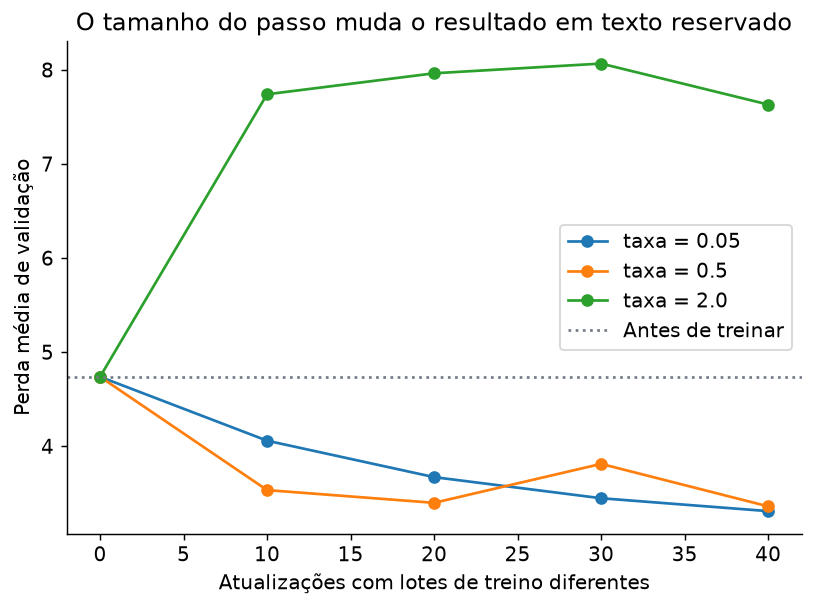

In [8]:
ordem_demo = np.random.default_rng(1000).permutation(len(Xtr))
lotes_demo = ordem_demo[:40 * 64].reshape(40, 64)
passos_demo = [0, 10, 20, 30, 40]
curvas_demo = {}
print("Perda de validação no início e após 10, 20, 30 e 40 atualizações:")
for eta in (0.05, 0.5, 2.0):
    demo = ModeloMLP(V, k=K, e=16, h=600, semente=0)
    perdas = [avaliar(demo, Xva, Yva)]
    for passo_demo, idx in enumerate(lotes_demo, start=1):  # 1. lote
        demo.perda(Xtr[idx], Ytr[idx])                    # 2. previsão e perda
        g = demo.gradientes(Ytr[idx])                     # 3. gradiente
        for nome in demo.p:
            demo.p[nome] -= eta * g[nome]                 # 4. atualização
        if passo_demo % 10 == 0:
            perdas.append(avaliar(demo, Xva, Yva))
    curvas_demo[eta] = perdas
    print(f"Taxa {eta}: " + " → ".join(f"{p:.2f}" for p in perdas))
    plt.plot(passos_demo, perdas, marker="o", label=f"taxa = {eta}")
plt.axhline(perdas[0], color="#737B85", linestyle=":", label="Antes de treinar")
plt.xlabel("Atualizações com lotes de treino diferentes")
plt.ylabel("Perda média de validação")
plt.title("O tamanho do passo muda o resultado em texto reservado")
plt.legend()
plt.tight_layout()
plt.show()

## 6. O treino completo: repetir o passo com outros lotes

| Decisão | Significado neste treino |
|---|---|
| **Batch / lote** | 64 exemplos usados para calcular cada atualização |
| **Step / passo** | Uma atualização dos parâmetros |
| **Epoch / época** | Uma passagem pelos exemplos de treino |
| **Learning rate / taxa** | A escala da atualização; aqui começa pequena, sobe e depois cai |
| **Seed / semente** | O ponto de partida dos sorteios dos pesos e dos lotes |
| **Orçamento** | O limite de passos e de exemplos processados |

Usaremos 6.000 passos para enxergar também o que acontece quando o treino continua além do melhor resultado. A cada 50 passos, mediremos os conjuntos inteiros e guardaremos uma cópia dos melhores pesos. A validação **não chama o otimizador**.

As sementes dos pesos e dos lotes são separadas. Fixá-las ajuda a repetir o experimento; bibliotecas e hardware diferentes ainda podem causar pequenas diferenças numéricas.

In [9]:
#@title Otimizador e taxa ao longo do treino (execute; leitura opcional)
class Adam:
    """Adam: médias móveis do gradiente e do gradiente ao quadrado."""

    def __init__(self, params, b1=0.9, b2=0.95, eps=1e-8, decaimento=0.0):
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.b1, self.b2, self.eps, self.wd, self.t = b1, b2, eps, decaimento, 0

    def passo(self, params, grads, lr):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            mh = self.m[k] / (1 - self.b1 ** self.t)
            vh = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= lr * (mh / (np.sqrt(vh) + self.eps) + self.wd * params[k])

def taxa(passo, total, lr_max, aquecimento, constante=False):
    """Aquecimento linear + decaimento cosseno ate 10% (fração do pico)."""
    if constante:
        return lr_max
    if passo < aquecimento:
        return lr_max * (passo + 1) / aquecimento
    prog = (passo - aquecimento) / max(1, total - aquecimento)
    return lr_max * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * prog)))
print("Adam e cronograma prontos.")

Adam e cronograma prontos.


In [10]:
# Mude uma decisão por vez e depois execute tudo novamente.
PASSOS = 6000
LOTE = 64
LR_MAX = 0.003
SEMENTE = 0
H = 600
AVALIAR_CADA = 50
AQUECIMENTO = 100

N = len(Xtr)
assert PASSOS > AQUECIMENTO and 1 <= LOTE <= N
passos_formatados = f"{PASSOS:,}".replace(",", ".")
alvos_formatados = f"{PASSOS * LOTE:,}".replace(",", ".")
print(f"Orçamento: {passos_formatados} passos × {LOTE} exemplos = {alvos_formatados} alvos processados")
print(f"Exposição equivalente: {PASSOS * LOTE / N:.2f} épocas")
print(f"Cada embaralhamento usa {N // LOTE} lotes completos; sobram {N % LOTE} exemplos.")

Orçamento: 6.000 passos × 64 exemplos = 384.000 alvos processados
Exposição equivalente: 15.85 épocas
Cada embaralhamento usa 378 lotes completos; sobram 33 exemplos.


### O laço que faz o modelo aprender

Leia as quatro linhas numeradas no final: **selecionar lote, prever e medir, calcular gradiente, atualizar pesos**.
O restante organiza a avaliação e guarda resultados. Em cada novo embaralhamento, este código descarta o lote incompleto. Por isso, a conta `passos × lote / exemplos` indica **épocas equivalentes**, não o número exato de visitas de cada exemplo.

O checkpoint abaixo é uma **cópia de pesos na memória**, suficiente para avaliar o melhor modelo. Para retomar um treino após fechar o programa, seria preciso salvar em disco também o estado do Adam, o passo, o estado dos geradores aleatórios e a posição/ordem dos dados.

In [11]:
modelo = ModeloMLP(V, k=K, e=16, h=H, semente=SEMENTE)
print(f"Modelo deste treino: H = {H}; {modelo.n_params():,} parâmetros".replace(",", "."))
otimizador = Adam(modelo.p)
rng_lotes = np.random.default_rng(SEMENTE + 1000)
ordem, pos = rng_lotes.permutation(N), 0
historico = {"passo": [], "treino": [], "val": []}
melhor = {"val": float("inf"), "passo": -1, "pesos": None}
pesos_inicio = {k: v.copy() for k, v in modelo.p.items()}
checkpoints = []
inicio = time.perf_counter()

for passo in range(PASSOS + 1):
    if passo % AVALIAR_CADA == 0 or passo == PASSOS:
        lt = avaliar(modelo, Xtr, Ytr)
        lv = avaliar(modelo, Xva, Yva)
        historico["passo"].append(passo)
        historico["treino"].append(lt)
        historico["val"].append(lv)
        if lv < melhor["val"]:
            melhor = {"val": lv, "passo": passo,
                      "pesos": {k: v.copy() for k, v in modelo.p.items()}}
            checkpoints.append(passo)
        if passo % 1000 == 0 or passo == PASSOS:
            print(f"Passo {passo:4d}: treino {lt:.3f}; validação {lv:.3f}")
    if passo == PASSOS:
        break

    if pos + LOTE > N:
        ordem, pos = rng_lotes.permutation(N), 0
    idx = ordem[pos:pos + LOTE]                              # 1. lote
    pos += LOTE
    perda_lote = modelo.perda(Xtr[idx], Ytr[idx])            # 2. previsão e perda
    g = modelo.gradientes(Ytr[idx])                         # 3. gradiente
    eta = taxa(passo, PASSOS, LR_MAX, AQUECIMENTO)
    otimizador.passo(modelo.p, g, eta)                       # 4. atualização

tempo_treino = time.perf_counter() - inicio
print(f"\nTreino concluído em {tempo_treino:.1f} s")
print(f"Melhor checkpoint: passo {melhor['passo']}, validação {melhor['val']:.3f}")

Modelo deste treino: H = 600; 147.738 parâmetros
Passo    0: treino 4.740; validação 4.738
Passo 1000: treino 1.590; validação 2.381
Passo 2000: treino 0.898; validação 2.375
Passo 3000: treino 0.494; validação 2.482
Passo 4000: treino 0.321; validação 2.624
Passo 5000: treino 0.235; validação 2.689
Passo 6000: treino 0.202; validação 2.725

Treino concluído em 75.1 s
Melhor checkpoint: passo 1100, validação 2.311


## 7. A avaliação: continuar treinando sempre ajuda?

As duas curvas usam a mesma métrica: perda média por alvo. A curva de treino usa os exemplos que atualizam os pesos; a de validação usa documentos reservados.

**Antes de ler a interpretação:** localize o menor ponto da curva de validação. Depois veja o que acontece com a curva de treino quando a validação começa a piorar.

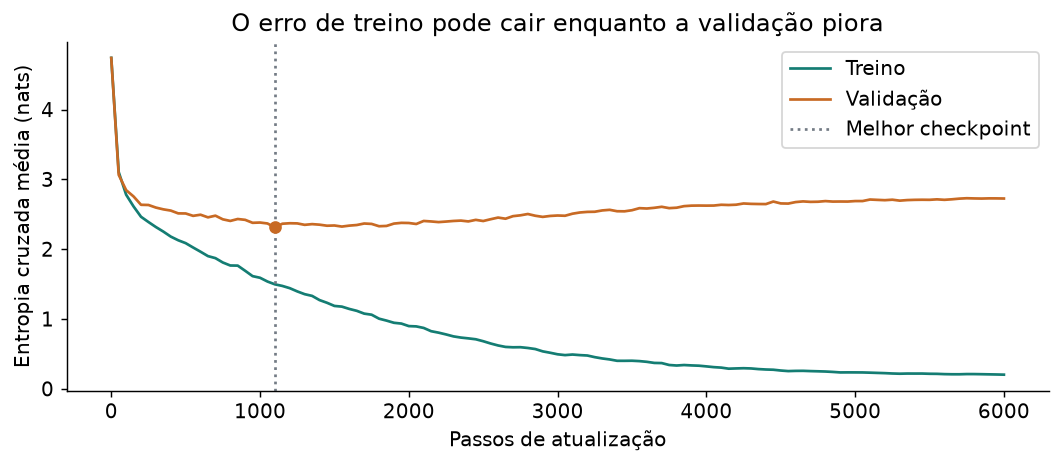

Melhor validação: 2.311 (perplexidade 10.09)
Última validação: 2.725 (perplexidade 15.26)


In [12]:
fig, ax = plt.subplots(figsize=(8.3, 3.7))
ax.plot(historico["passo"], historico["treino"], color=COR_TREINO, label="Treino")
ax.plot(historico["passo"], historico["val"], color=COR_VAL, label="Validação")
ax.axvline(melhor["passo"], color="#737B85", linestyle=":", label="Melhor checkpoint")
ax.scatter([melhor["passo"]], [melhor["val"]], color=COR_VAL, zorder=5)
ax.set(xlabel="Passos de atualização", ylabel="Entropia cruzada média (nats)",
       title="O erro de treino pode cair enquanto a validação piora")
ax.legend()
fig.tight_layout()
plt.show()
print(f"Melhor validação: {melhor['val']:.3f} (perplexidade {np.exp(melhor['val']):.2f})")
print(f"Última validação: {historico['val'][-1]:.3f} (perplexidade {np.exp(historico['val'][-1]):.2f})")

**Como interpretar:** quando treino e validação melhoram juntos, há evidência de melhora em documentos reservados. Quando o treino continua melhorando e a validação piora de forma persistente, vemos **overfitting**: o modelo não consegue generalizar e está decorando o dataset de treino. Tentar aumentar a quantidade de dados, regularização e dropout são formas de tentar amenizar isso.

Se ambos permanecem ruins, pode haver **underfitting**, mas também treino insuficiente ou otimização inadequada. Tentar aumentar a capacidade do modelo pode ajudar no underfitting

Aqui concluímos todos os passos e **selecionamos o melhor checkpoint**. *Early stopping* seria interromper o treino quando a validação deixasse de melhorar, segundo uma regra previamente definida, por exemplo uma tolerância de várias avaliações.

Agora compare uma previsão e um texto gerado em três estados: início, melhor checkpoint e final.

**Como ler a próxima saída:**

- **Início:** a mistura de letras, números e símbolos é esperada. Os pesos ainda são aleatórios e todos esses caracteres pertencem ao vocabulário. A saída não indica um problema de codificação.
- **Melhor:** significa menor perda de validação entre os estados avaliados. Este modelo pequeno ainda escreve palavras incorretas e frases sem sentido.
- **Final:** pode acertar melhor um caractere específico e, mesmo assim, ter perda média pior na validação.

São duas observações separadas: medimos a probabilidade de `m` após `de linguage` (a rede usa só os últimos 8 caracteres, `linguage`) e geramos uma amostra **a partir do início de um documento**, sem esse prefixo, ou seja, gerar tokens do zero. A geração sorteia um caractere por vez, com temperatura 0,8, que concentra as probabilidades nas opções mais prováveis. Ela termina em `¶` ou após 160 caracteres, podendo parar no meio de uma palavra. As quebras de linha abaixo servem apenas para facilitar a leitura.

Início — probabilidade de 'm' após 'de linguage': 0.9%
Pesos aleatórios: a mistura de caracteres abaixo é esperada.
Amostra gerada do início de um documento:
2cn%4Σ+1—oMbvA3Çtbàf√8f_Nl<Íé1YB,ôT3s;ô:%:JZõxK"5≈Vu)%ãlFG-7%áY0·;)lõ"É;-
Dx[ç<J>√—IUF·&+P?áÀdsxÃ—3n4VÇôÁ&L5≈1?K)íp5]-m=&1epGsN2IPú0-h↔ôy)×u4[(É 

Melhor — probabilidade de 'm' após 'de linguage': 80.0%
Amostra gerada do início de um documento:
Mena sabtecos conteito e o preinar a mina e sem do s bula co volho do sle guro
fdoselas AlIrece tãkenho que é modimal mia, mameio vecosis poriantenteia
marmaime 

Final — probabilidade de 'm' após 'de linguage': 95.5%
Amostra gerada do início de um documento:
A resposta fechada e as trincas que ele aprende Uuma Tuan) e recebe. Note que
'céu' salide perguntarem: paráua ser atenção e2 legução — nassatarde a softmax
exa 



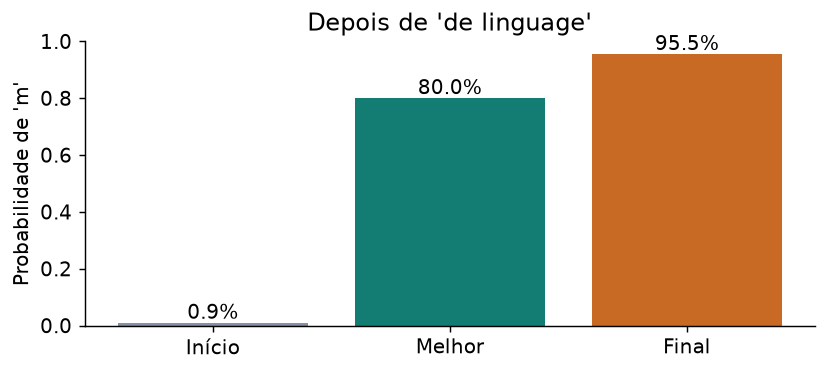

In [13]:
def gerar(modelo, chars, stoi, n=160, T=0.8, semente=0, prefixo="", params=None):
    rng = np.random.default_rng(semente)
    ctx = [stoi[SEP]] * modelo.k + [stoi[c] for c in prefixo]
    out = list(prefixo)
    for _ in range(n):
        z, _, _ = modelo.logits(np.array([ctx[-modelo.k:]]), params)
        z = z[0] / T
        q = np.exp(z - z.max())
        q /= q.sum()
        i = int(rng.choice(len(q), p=q))
        if chars[i] == SEP:
            break
        out.append(chars[i])
        ctx.append(i)
    return "".join(out)

estados = [("Início", pesos_inicio), ("Melhor", melhor["pesos"]), ("Final", modelo.p)]
prob_m = []
for nome, pesos in estados:
    pm = probabilidades(modelo, CONTEXTO, pesos)[stoi["m"]]
    prob_m.append(pm)
    texto = gerar(modelo, chars, stoi, n=160, T=0.8, semente=11, params=pesos)
    print(f"{nome} — probabilidade de 'm' após {CONTEXTO!r}: {pm:.1%}")
    if nome == "Início":
        print("Pesos aleatórios: a mistura de caracteres abaixo é esperada.")
    print("Amostra gerada do início de um documento:")
    print(fill(texto.replace("\n", " "), width=80), "\n")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar([nome for nome, _ in estados], prob_m, color=["#8592A3", COR_TREINO, COR_VAL])
ax.set(ylim=(0, 1), ylabel="Probabilidade de 'm'", title=f"Depois de {CONTEXTO!r}")
for i, p in enumerate(prob_m):
    ax.text(i, p + 0.015, f"{p:.1%}", ha="center")
fig.tight_layout()
plt.show()

Podemos ver que o modelo do final tem um pouco mais de coerencia nos tokens gerados, mas mesmo assim, por ser um modelo pequeno, tem dificuldade de escolher tokens para formar algo que faça sentido. Ele mais acerta palavras do que frases.